In [2]:
import icdv as icdv
import matplotlib.pyplot as plt
import numpy as np

In [3]:
%matplotlib widget

In [4]:
# 2) Cargar todos los CSV (rápido)
df_all = icdv.processing.cargar_csv_arbin("/home/mariajose/proc-icdv/notebooks/tmp/ARBIN_jd_grcom_sw3_c_1_sinresorte_doslanavidrio")
df_all.head()

# 3) Procesar
dict_ciclos, dict_ciclos_sep, indices = icdv.processing.procesar_arbin(df_all)

print(len(indices))
print(indices[0:15])
print(indices[len(indices)-15:len(indices)])
print(dict_ciclos_sep[1]['Ch'].head())

92
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]
      Time_s   Time_cont_s  Current_mA   CellV_V     Q_mAh     Energy_Wh  \
0  10.007428  47197.827208    0.316072  0.036467  0.000879  3.007180e-08   
1  20.009795  47207.829575    0.316072  0.039537  0.001757  6.356200e-08   
2  30.012624  47217.832404    0.316037  0.041993  0.002635  9.950061e-08   
3  40.013499  47227.833279    0.316072  0.044448  0.003513  1.374913e-07   
4  50.016886  47237.836666    0.316108  0.046597  0.004391  1.773201e-07   

    dVdt_Vs  dQdV_mAhV  
0  0.000000        NaN  
1  0.000000        NaN  
2  0.000000        NaN  
3  0.003039    0.02889  
4  0.000000        NaN  


In [5]:
# Quitar ciclos anómalos
indices_originales = indices.copy()
indices = [i for i in indices if i not in [1,2,3,6,38,39,40,41,45,46,47,48,49,92]]

print(indices_originales)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]


[4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


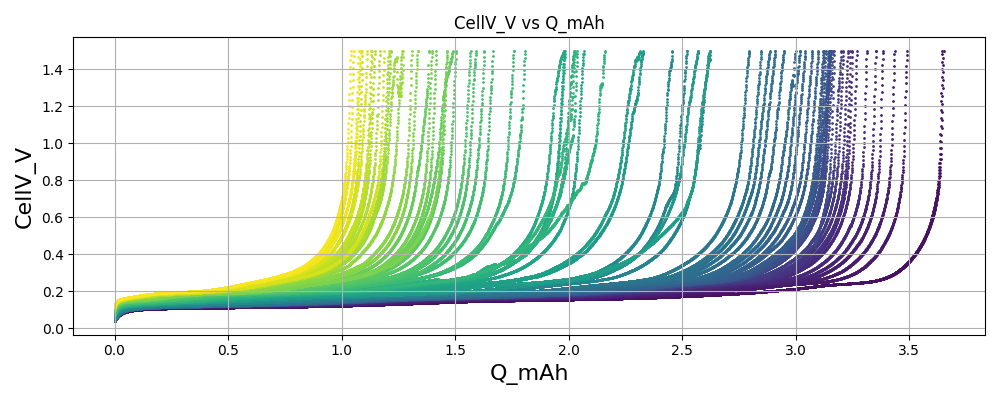

[4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


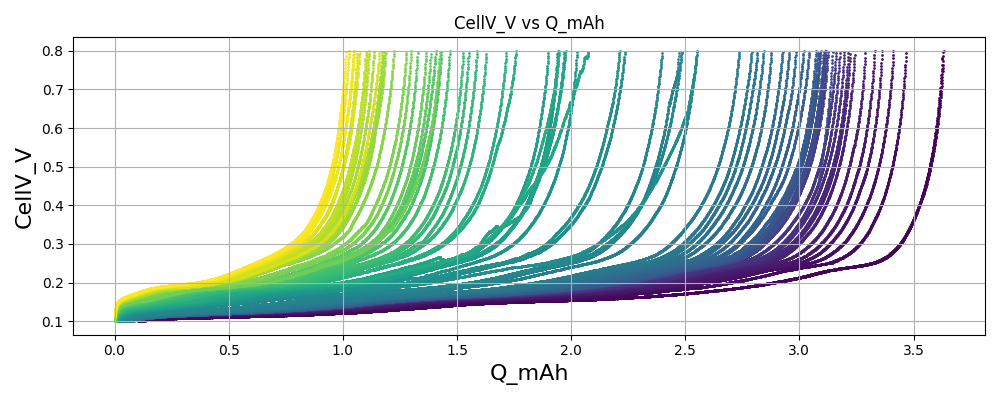

In [7]:
dict_ciclos_sep_truncado = icdv.deriv.truncar_ciclos_voltaje(indices, dict_ciclos_sep, v_cutoff_ch=[0.1, 0.8], v_cutoff_dis=[0.05, 0.8], CellV='CellV_V')

icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep, semi='Ch', vars=['Q_mAh', 'CellV_V'], nombre_grafico='plot', scatter=False)

icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep_truncado, semi='Ch', vars=['Q_mAh', 'CellV_V'], nombre_grafico='plot', scatter=False)

In [ ]:
import matplotlib.pyplot as plt

def grafico_individual(ciclo, x=dict_ciclos_sep[3]['Ch']['CellV_V'], y=dict_ciclos_sep[3]['Ch']['Q_mAh'], xlim=None, ylim=None):

    plt.figure(figsize=(6,5))
    plt.scatter(x,y, s=2)
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.title(f'Cycle {ciclo} - {x.name} vs {y.name}')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.show()


import matplotlib.cm as cm
import matplotlib.colors as mcolors

def grafico_multiples(indices, dict_ciclos_sep, semi='both', x='CellV_V', y='Q_mAh', xlim=None, ylim=None):

    plt.figure(figsize=(6,5))
    
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(indices))) # paleta completa (uno por cada ciclo real)
    color_map = {c: colors[i] for i, c in enumerate(indices)} # map: ciclo_real -> color_correcto

    for i in indices:
        color = color_map[i]
        df_ch = dict_ciclos_sep[i]['Ch']
        df_dis = dict_ciclos_sep[i]['Dis']
        
        if semi == 'both':
            #plt.plot(df_ch[x],df_ch[y], color=color,label=f'Cycle {i}', linewidth=1)
            #plt.plot(df_dis[x],df_dis[y], color=color, linewidth=1)
            plt.scatter(df_ch[x],df_ch[y], color=color,label=f'Cycle {i}', s=2)
            plt.scatter(df_dis[x],df_dis[y], color=color, s=2)
        elif semi == 'Ch':
            #plt.plot(df_ch[x],df_ch[y], color=color,label=f'Cycle {i}', linewidth=1)
            plt.scatter(df_ch[x],df_ch[y], color=color,label=f'Cycle {i}', s=2)
        elif semi == 'Dis':
            #plt.plot(df_dis[x],df_dis[y], color=color,label=f'Cycle {i}', linewidth=1)
            plt.scatter(df_dis[x],df_dis[y], color=color, s=2)
        else:
            print(f"Error: semi debe ser 'both', 'Ch' o 'Dis'. Valor recibido: {semi}")
        
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'Cicos {indices[0]}-{indices[-1]} - {x} vs {y}')
    plt.xlim(xlim)
    plt.ylim(ylim)
    #plt.legend()
    plt.grid()
    plt.show()